## Apply All Data Preprocessing Steps to insurance dataset 

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler,StandardScaler,LabelEncoder

### Data Understanding

In [5]:
df=pd.read_csv("data/raw/insurance.csv")

In [6]:
print(df.shape)
print(df.columns)

(1338, 7)
Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [8]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [9]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


### Drop Non Intereseted Columns
In this data i see all features are affected target value so i don't drop any column

### Check dtypes

In [10]:
display(df.dtypes)
display(df.nunique())

age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

age           47
sex            2
bmi          548
children       6
smoker         2
region         4
charges     1337
dtype: int64

### Handle dtypes

In [11]:
Category_cols=['sex','smoker','region']
df[Category_cols]=df[Category_cols].astype('category')
display(df.dtypes)

age            int64
sex         category
bmi          float64
children       int64
smoker      category
region      category
charges      float64
dtype: object

### Check Null Values

In [12]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

### Handle Null Values 
but in this data doesn't have null values

### Check Outliers

<Axes: ylabel='children'>

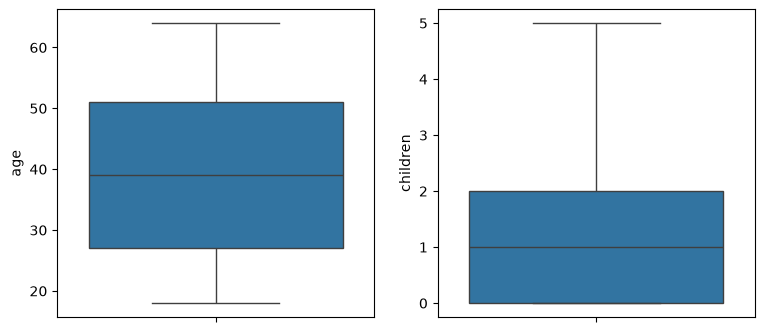

In [13]:
## Using boxplot Visualization to detect outliers

plt.figure(figsize=(9,4))
plt.subplot(1,2,1)
sns.boxplot(data=df['age'],orient='v')
plt.subplot(1,2,2)
sns.boxplot(data=df['children'],orient='v')

In [14]:
Q1 = df["age"].quantile(0.25)
Q3 = df["age"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = df[
    (df["age"] < lower) |
    (df["age"] > upper)
]
print("Number of outliers:", len(outliers))
print("============================================")
Q1 = df["children"].quantile(0.25)
Q3 = df["children"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = df[
    (df["children"] < lower) |
    (df["children"] > upper)
]
print("Number of outliers:", len(outliers))

Number of outliers: 0
Number of outliers: 0


### Handle Outliers 
data doens't have outliers 

### Check Duplicated rows

In [15]:
df.duplicated().sum()

np.int64(1)

### Handle Duplicated rows

In [16]:
df.drop_duplicates(inplace=True,keep='first')
df.duplicated().sum()

np.int64(0)

### Data Visualization

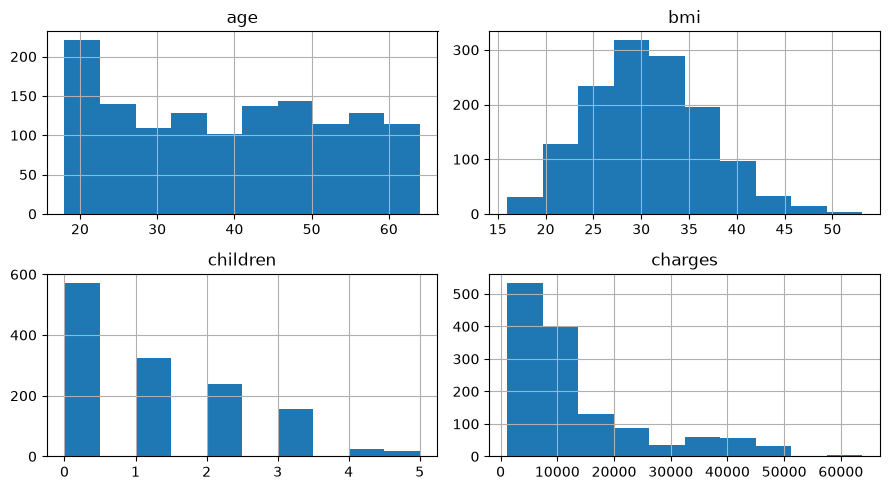

In [17]:
# Distribution of numerical data 
plt.figure(figsize=(9,5))

plt.subplot(2,2,1)
df["age"].hist()
plt.title("age")

plt.subplot(2,2,2)
df["bmi"].hist()
plt.title("bmi")

plt.subplot(2,2,3)
df["children"].hist()
plt.title("children")

plt.subplot(2,2,4)
df["charges"].hist()
plt.title("charges")

plt.tight_layout()


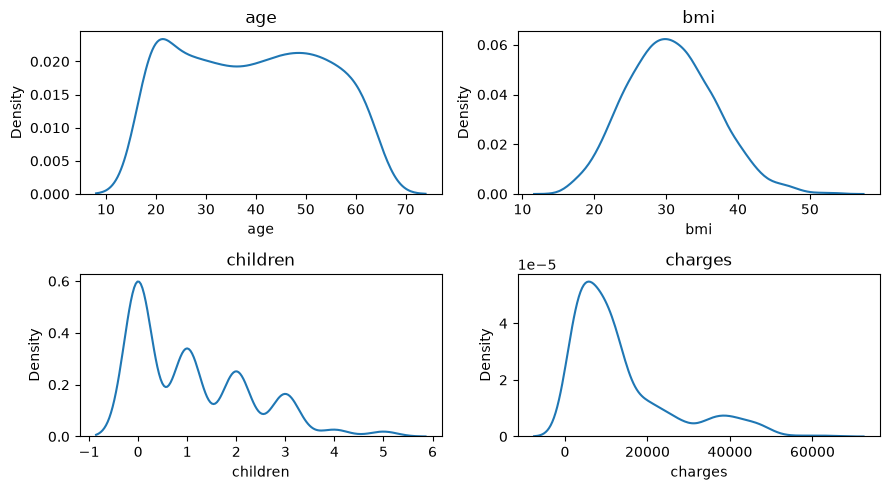

In [18]:
# Distribution of numerical data 
plt.figure(figsize=(9,5))

plt.subplot(2,2,1)
sns.kdeplot(df['age'])
plt.title("age")

plt.subplot(2,2,2)
sns.kdeplot(df['bmi'])
plt.title("bmi")

plt.subplot(2,2,3)
sns.kdeplot(df['children'])
plt.title("children")

plt.subplot(2,2,4)
sns.kdeplot(df['charges'])
plt.title("charges")

plt.tight_layout()

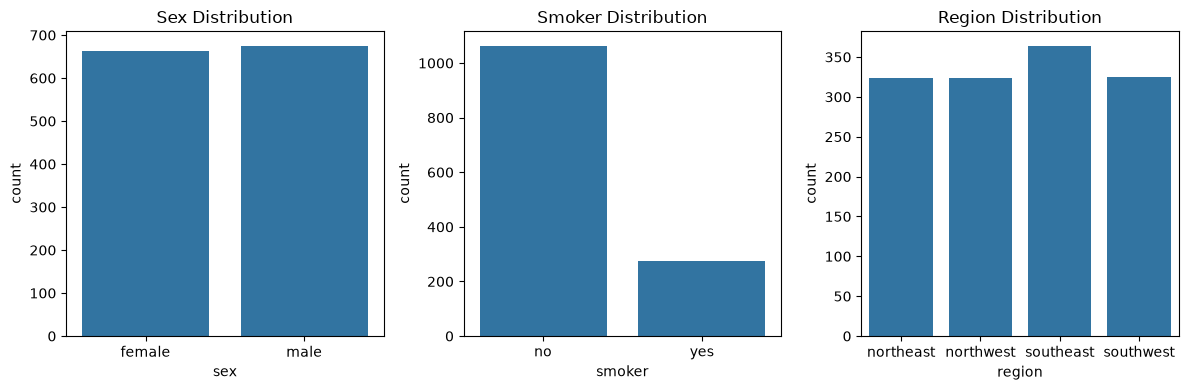

In [19]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
sns.countplot(data=df, x="sex")
plt.title("Sex Distribution")

plt.subplot(1, 3, 2)
sns.countplot(data=df, x="smoker")
plt.title("Smoker Distribution")

plt.subplot(1, 3, 3)
sns.countplot(data=df, x="region")
plt.title("Region Distribution")

plt.tight_layout()

sex
male      675
female    662
Name: count, dtype: int64
[675 662]
CategoricalIndex(['male', 'female'], categories=['female', 'male'], ordered=False, dtype='category', name='sex')
smoker
no     1063
yes     274
Name: count, dtype: int64
[1063  274]
CategoricalIndex(['no', 'yes'], categories=['no', 'yes'], ordered=False, dtype='category', name='smoker')
region
southeast    364
southwest    325
northeast    324
northwest    324
Name: count, dtype: int64
[364 325 324 324]
CategoricalIndex(['southeast', 'southwest', 'northeast', 'northwest'], categories=['northeast', 'northwest', 'southeast', 'southwest'], ordered=False, dtype='category', name='region')


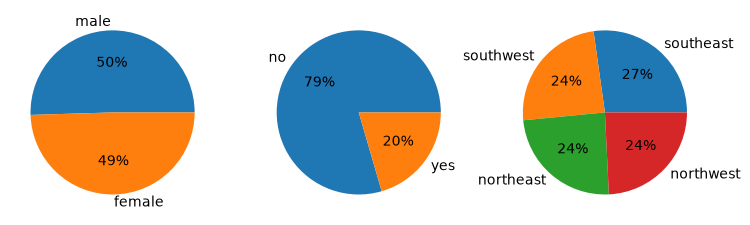

In [20]:
plt.figure(figsize=(9,4))

for i , col in enumerate(Category_cols):
    plt.subplot(1,3,i+1)
    unique=df[col].value_counts()
    counts=unique.values
    category=unique.index
    print(unique)
    print(counts)
    print(category)
    print("==========================")
    plt.pie(counts,labels=category,autopct='%1.1d%%')

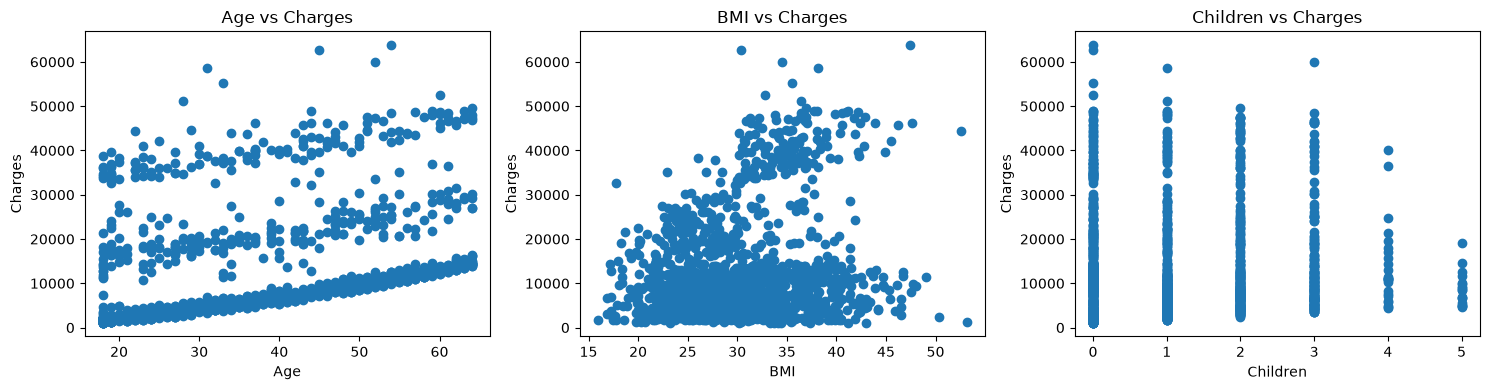

In [21]:
# Relationship graphs


plt.figure(figsize=(15, 4))

# Age vs Charges
plt.subplot(1, 3, 1)
plt.scatter(df["age"], df["charges"])
plt.title("Age vs Charges")
plt.xlabel("Age")
plt.ylabel("Charges")

# BMI vs Charges
plt.subplot(1, 3, 2)
plt.scatter(df["bmi"], df["charges"])
plt.title("BMI vs Charges")
plt.xlabel("BMI")
plt.ylabel("Charges")

# Children vs Charges
plt.subplot(1, 3, 3)
plt.scatter(df["children"], df["charges"])
plt.title("Children vs Charges")
plt.xlabel("Children")
plt.ylabel("Charges")

plt.tight_layout()
plt.show()

### Data Spliting

In [22]:
X=df.drop(['charges'],axis=1)
y=df[['charges']]

In [23]:
display(X)
display(y)


,age,sex,bmi,children,smoker,region
0,19,female,27.900,0,yes,southwest
1,18,male,33.770,1,no,southeast
2,28,male,33.000,3,no,southeast
3,33,male,22.705,0,no,northwest
4,32,male,28.880,0,no,northwest
...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest
1334,18,female,31.920,0,no,northeast
1335,18,female,36.850,0,no,southeast
1336,21,female,25.800,0,no,southwest


,charges
0,16884.92400
1,1725.55230
2,4449.46200
3,21984.47061
4,3866.85520
...,...
1333,10600.54830
1334,2205.98080
1335,1629.83350
1336,2007.94500


### Data Normalization

In [ ]:
# first using MinMaxScaler
numerical_cols=['age','bmi']

scaler=MinMaxScaler()

for col in numerical_cols:
    df[col]=scaler.fit_transform(df[numerical_cols])

In [32]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,0.021739,female,0.321227,0,yes,southwest,0.021739
1,0.000000,male,0.479150,1,no,southeast,0.000000
2,0.217391,male,0.458434,3,no,southeast,0.217391
3,0.326087,male,0.181464,0,no,northwest,0.326087
4,0.304348,male,0.347592,0,no,northwest,0.304348


### Encoding

In [33]:

encoder=LabelEncoder()

for col in Category_cols:
    df[col]=encoder.fit_transform(df[col])

In [34]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,0.021739,0,0.321227,0,1,3,0.021739
1,0.000000,1,0.479150,1,0,2,0.000000
2,0.217391,1,0.458434,3,0,2,0.217391
3,0.326087,1,0.181464,0,0,1,0.326087
4,0.304348,1,0.347592,0,0,1,0.304348
